# Recourse Dataset + Level 1: Prediction Fairness

**Author:** Matteo

Integrates with the team's pipeline:
  - Reads `.npy` splits from `data/processed/` (output of 1_Preprocessing.ipynb)
  - Reads model artifacts from `data/models/RF/` and `data/models/XGBoost/`
    (output of 2_Random_Forest.ipynb and 2_XGboost.ipynb)
  - Reads counterfactual setup from utils.py (reuses Kamila's DiCE functions)
  - Saves results to `data/fairness/`

## Setup
## Install dependencies

In [25]:
import os
import subprocess, sys

# Install missing packages if needed (works both locally and on Colab)
subprocess.run([sys.executable, "-m", "pip", "install", "dice-ml", "xgboost", "-q"])


CompletedProcess(args=['c:\\Users\\kamil\\Desktop_new\\Local\\Universidad\\H512 Current Trends\\infoh512-project\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'dice-ml', 'xgboost', '-q'], returncode=0)

## Load Utils and others

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml
from utils import THRESHOLD_RF, THRESHOLD_XGB
import utils
from utils import (
    ScaledModelWrapper, load_artifacts, load_raw_with_split,
    build_recourse_dataset, get_project_paths,
    PROTECTED_ATTRIBUTES, SEED_DICE,
)

# Auto-detects Colab vs local VSCode and returns the correct paths
PATHS = get_project_paths()

print("Project paths:")
for k, v in PATHS.items():
    print(f"  {k}: {v}")

THRESHOLD_RF = THRESHOLD_RF
THRESHOLD_XGB = THRESHOLD_XGB
N_CF      = 3


Project paths:
  BASE: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project
  DATA: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
  RF: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\RF
  XGBoost: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost
  FAIRNESS: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness


## Load data
**(readable demographics) and model artifacts**

In [27]:
df_raw, df_encoded, feature_cols = load_raw_with_split()
print(f"Dataset: {df_raw.shape[0]} employees, {len(feature_cols)} features")
print(f"True attrition rate: {df_raw['Attrition'].mean():.1%}")

Dataset: 1470 employees, 30 features
True attrition rate: 16.1%


In [28]:
rf  = load_artifacts(PATHS["RF"])
xgb = load_artifacts(PATHS["XGBoost"])
feature_names = rf["feature_names"]

rf_wrapper  = ScaledModelWrapper(rf["model"],  rf["scaler"],  feature_names)
xgb_wrapper = ScaledModelWrapper(xgb["model"], xgb["scaler"], feature_names)
print("Models loaded successfully.")

Models loaded successfully.


# 1. DiCE
## 1.1. Build Explainers
**(reusing the team's exact configuration)**

In [29]:
dice_df = df_encoded[feature_names].astype("float64").copy()
dice_df["Attrition"] = df_encoded["Attrition"].values

dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=list(feature_names),
    outcome_name="Attrition",
)
dice_rf  = dice_ml.Model(model=rf_wrapper,  backend="sklearn", model_type="classifier")
dice_xgb = dice_ml.Model(model=xgb_wrapper, backend="sklearn", model_type="classifier")
exp_rf  = dice_ml.Dice(dice_data, dice_rf,  method="random")
exp_xgb = dice_ml.Dice(dice_data, dice_xgb, method="random")

print("DiCE explainers ready.")

DiCE explainers ready.


## 1.2. Generate recourse dataset on ALL at-risk employees

⚠️ This is the slow step. Results are checkpointed every 25 employees so a crash never loses all progress.

In [ ]:
recourse_rf = build_recourse_dataset(
    exp_rf, rf_wrapper, df_encoded, df_raw, feature_names,
    le_dict=rf["label_encoders"], n_cf=N_CF, seed=SEED_DICE,
    threshold=THRESHOLD_RF,
    checkpoint_path=os.path.join(PATHS["FAIRNESS"], "recourse_RF.csv"),
)

Employees flagged at-risk (proba >= 0.489): 249


  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
recourse_xgb = build_recourse_dataset(
    exp_xgb, xgb_wrapper, df_encoded, df_raw, feature_names,
    le_dict=xgb["label_encoders"], n_cf=N_CF, seed=SEED_DICE,
    threshold=THRESHOLD_XGB,
    checkpoint_path=os.path.join(PATHS["FAIRNESS"], "recourse_XGB.csv"),
)

Employees flagged at-risk (proba >= 0.592): 325
  processed 25 / 325
  processed 50 / 325
  processed 75 / 325
  processed 100 / 325
  processed 125 / 325
  processed 150 / 325
  processed 175 / 325
  processed 200 / 325
  processed 225 / 325
  processed 250 / 325
  processed 275 / 325
  processed 300 / 325
  processed 325 / 325
Saved -> c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\fairness\recourse_XGB.csv


In [ ]:
print(f"\nDone. RF: {len(recourse_rf)} employees | XGB: {len(recourse_xgb)} employees")
recourse_rf.head()


Done. RF: 249 employees | XGB: 325 employees


,emp_id,Gender,AgeGroup,Age,MaritalStatus,Department,true_attrition,predicted_risk,n_cf_found,recourse_found,L1_cost,changed_feats
0,0,Female,Senior,41,Single,Sales,1,74.1,0,False,NaN,
1,2,Male,Senior,37,Single,Research & Development,1,61.1,0,False,NaN,
2,14,Male,Young,28,Single,Research & Development,1,88.5,0,False,NaN,
3,23,Male,Young,21,Single,Research & Development,0,55.7,0,False,NaN,
4,24,Male,Young,34,Single,Research & Development,1,63.8,0,False,NaN,


# 2. Prediction Fairnerss
## 2.1. By group-fairness
Three group-fairness notions (from the lecture slides):
- **Statistical parity:** same predicted-positive rate per group
- **Equal opportunity:** same recall (TPR) per group
- **Predictive equality:** same FPR per group

In [ ]:
def prediction_fairness(wrapper, df_encoded, df_raw, feature_names,
                        protected_attr, threshold):
    X      = df_encoded[feature_names].astype("float64")
    proba  = wrapper.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    y_true = df_raw["Attrition"].values
    rows   = []
    for g in sorted(df_raw[protected_attr].dropna().unique()):
        mask = (df_raw[protected_attr] == g).values
        yt, yp = y_true[mask], y_pred[mask]
        pos, neg = yt == 1, yt == 0
        rows.append({
            protected_attr:        g,
            "n":                   int(mask.sum()),
            "pred_positive_rate":  round(yp.mean(), 3),
            "TPR_recall":          round(yp[pos].mean(), 3) if pos.any() else float("nan"),
            "FPR":                 round(yp[neg].mean(), 3) if neg.any() else float("nan"),
        })
    return pd.DataFrame(rows)

In [ ]:
for model_name, wrapper in [("Random Forest", rf_wrapper), ("XGBoost", xgb_wrapper)]:
    print(f"\n{'='*60}\n{model_name} — Prediction Fairness\n{'='*60}")
    for attr in PROTECTED_ATTRIBUTES:
        tbl = prediction_fairness(wrapper, df_encoded, df_raw, feature_names, attr,threshold= THRESHOLD_RF if model_name == "Random Forest" else THRESHOLD_XGB)
        gaps = {m: round(tbl[m].max() - tbl[m].min(), 3)
                for m in ["pred_positive_rate", "TPR_recall", "FPR"]}
        print(f"\n-- {attr} --")
        print(tbl.to_string(index=False))
        print(f"   gaps (max-min): {gaps}")


Random Forest — Prediction Fairness

-- Gender --
Gender   n  pred_positive_rate  TPR_recall   FPR
Female 588               0.163        0.92 0.032
  Male 882               0.173        0.90 0.025
   gaps (max-min): {'pred_positive_rate': np.float64(0.01), 'TPR_recall': np.float64(0.02), 'FPR': np.float64(0.007)}

-- AgeGroup --
AgeGroup   n  pred_positive_rate  TPR_recall   FPR
  Senior 819               0.092       0.828 0.004
   Young 651               0.267       0.953 0.062
   gaps (max-min): {'pred_positive_rate': np.float64(0.175), 'TPR_recall': np.float64(0.125), 'FPR': np.float64(0.058)}

-- MaritalStatus --
MaritalStatus   n  pred_positive_rate  TPR_recall   FPR
     Divorced 327               0.095       0.848 0.010
      Married 673               0.129       0.917 0.017
       Single 470               0.279       0.917 0.060
   gaps (max-min): {'pred_positive_rate': np.float64(0.184), 'TPR_recall': np.float64(0.069), 'FPR': np.float64(0.05)}

XGBoost — Prediction Fairness


## 2.2.Visualise predicted attrition rate by group

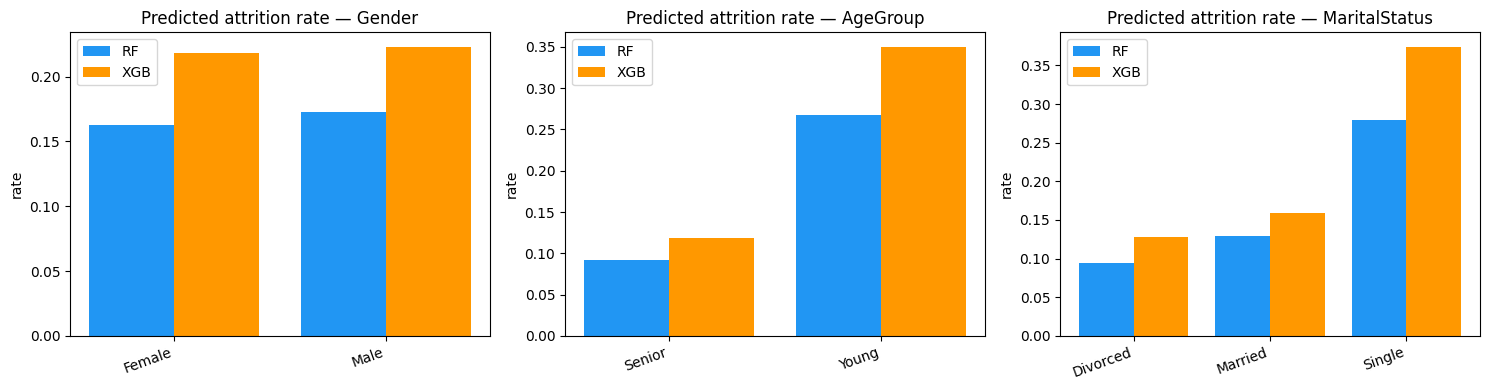

Level 1 done. Proceed to 05_counterfactual_fairness.ipynb


In [ ]:
fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                         figsize=(5 * len(PROTECTED_ATTRIBUTES), 4))
for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
    rf_tbl  = prediction_fairness(rf_wrapper,  df_encoded, df_raw, feature_names, attr, THRESHOLD_RF)
    xgb_tbl = prediction_fairness(xgb_wrapper, df_encoded, df_raw, feature_names, attr, THRESHOLD_XGB)
    x = np.arange(len(rf_tbl))
    ax.bar(x - 0.2, rf_tbl["pred_positive_rate"],  0.4, label="RF",  color="#2196F3")
    ax.bar(x + 0.2, xgb_tbl["pred_positive_rate"], 0.4, label="XGB", color="#FF9800")
    ax.set_xticks(x)
    ax.set_xticklabels(rf_tbl[attr], rotation=20, ha="right")
    ax.set_title(f"Predicted attrition rate — {attr}")
    ax.set_ylabel("rate")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PATHS["FAIRNESS"], "level1_prediction_fairness.png"), dpi=120)
plt.show()
print("Level 1 done. Proceed to 05_counterfactual_fairness.ipynb")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DIAGNOSTICA — validazione risultati notebook 04
# ─────────────────────────────────────────────────────────────────────────────
SEP = "=" * 65

# ── 1. DATASET ────────────────────────────────────────────────────────────────
print(SEP)
print("1. DATASET")
print(SEP)
print(f"  Totale dipendenti  : {len(df_raw)}")
print(f"  Feature usate      : {len(feature_names)}")
print(f"  Attrition reale    : {df_raw['Attrition'].sum()} / {len(df_raw)} ({df_raw['Attrition'].mean():.1%})")
print()
for attr in ['Gender', 'AgeGroup', 'MaritalStatus']:
    print(f"  {attr}:")
    print(df_raw[attr].value_counts().to_string())
    print()

# ── 2. MODELLI ────────────────────────────────────────────────────────────────
print(SEP)
print("2. SANITY CHECK MODELLI (threshold=0.20)")
print(SEP)
X_all  = df_encoded[feature_names].astype('float64')
y_true = df_raw['Attrition'].values

for name, wrapper in [('Random Forest', rf_wrapper), ('XGBoost', xgb_wrapper)]:
    proba = wrapper.predict_proba(X_all)[:, 1]
    pred  = (proba >= (THRESHOLD_RF if name == "Random Forest" else THRESHOLD_XGB)).astype(int)
    tp = ((pred==1) & (y_true==1)).sum()
    fp = ((pred==1) & (y_true==0)).sum()
    fn = ((pred==0) & (y_true==1)).sum()
    print(f"  {name}:")
    print(f"    At-risk predetti : {pred.sum()} ({pred.mean():.1%})")
    print(f"    Recall           : {tp/(tp+fn):.1%}  |  Precision: {tp/(tp+fp):.1%}")
    print(f"    Proba media      : {proba.mean():.3f}  |  max: {proba.max():.3f}")
    print()

# ── 3. RECOURSE DATASET ───────────────────────────────────────────────────────
print(SEP)
print("3. RECOURSE DATASET")
print(SEP)
for name, rdf in [('Random Forest', recourse_rf), ('XGBoost', recourse_xgb)]:
    found = rdf['recourse_found'].sum()
    total = len(rdf)
    costs = rdf.loc[rdf['recourse_found'], 'L1_cost']
    print(f"  {name}:")
    print(f"    At-risk processati : {total}")
    print(f"    Recourse trovato   : {found} ({found/total:.1%})")
    print(f"    Costo L1 medio     : {costs.mean():.4f}  |  mediano: {costs.median():.4f}")
    print()

# ── 4. FACTS PREVIEW ─────────────────────────────────────────────────────────
print(SEP)
print("4. FACTS PREVIEW — gap di fairness sul recourse")
print(SEP)
for name, rdf in [('Random Forest', recourse_rf), ('XGBoost', recourse_xgb)]:
    print(f"  {name}:")
    for attr in ['Gender', 'AgeGroup', 'MaritalStatus']:
        rows = []
        for g in sorted(rdf[attr].dropna().unique()):
            sub  = rdf[rdf[attr] == g]
            eff  = sub['recourse_found'].mean()
            cost = sub.loc[sub['recourse_found'], 'L1_cost'].median()
            rows.append((g, len(sub), eff, cost))
        print(f"    {attr}:")
        for g, n, eff, cost in rows:
            print(f"      {str(g):15s} n={n:4d}  eff={eff:.1%}  median_cost={cost:.4f}")
        gap = round(max(r[2] for r in rows) - min(r[2] for r in rows), 3)
        print(f"      → GAP: {gap}  {'⚠️  unfair' if gap > 0.05 else '✅ ok'}")
    print()

# ── 5. FILE SALVATI ───────────────────────────────────────────────────────────
print(SEP)
print("5. FILE SALVATI")
print(SEP)
for fname in sorted(os.listdir(PATHS['FAIRNESS'])):
    fpath = os.path.join(PATHS['FAIRNESS'], fname)
    print(f"  ✅ {fname}  ({os.path.getsize(fpath):,} bytes)")

1. DATASET
  Totale dipendenti  : 1470
  Feature usate      : 30
  Attrition reale    : 237 / 1470 (16.1%)

  Gender:
Gender
Male      882
Female    588

  AgeGroup:
AgeGroup
Senior    819
Young     651

  MaritalStatus:
MaritalStatus
Married     673
Single      470
Divorced    327

2. SANITY CHECK MODELLI (threshold=0.20)
  Random Forest:
    At-risk predetti : 249 (16.9%)
    Recall           : 90.7%  |  Precision: 86.3%
    Proba media      : 0.253  |  max: 0.971

  XGBoost:
    At-risk predetti : 325 (22.1%)
    Recall           : 83.1%  |  Precision: 60.6%
    Proba media      : 0.414  |  max: 0.958

3. RECOURSE DATASET
  Random Forest:
    At-risk processati : 249
    Recourse trovato   : 3 (1.2%)
    Costo L1 medio     : 0.0000  |  mediano: 0.0000

  XGBoost:
    At-risk processati : 325
    Recourse trovato   : 77 (23.7%)
    Costo L1 medio     : 0.0000  |  mediano: 0.0000

4. FACTS PREVIEW — gap di fairness sul recourse
  Random Forest:
    Gender:
      Female          n=  96